Here, we filter the scvi anndata object according to the extracted signaling network. We also embed the activity matrix in PCA/UMAP space.

In [1]:
import os
import ast
import json
import time

from tqdm import tqdm
from tqdm import trange

import numpy as np
import pandas as pd

import scanpy as sc
# import umap

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
# from scLEMBAS import preprocess as pp
from scLEMBAS import latent_separation as ls

/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_cores = 80
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

In [3]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))

<span style="color:red; font-weight:bold">Delete This:</span>


In [4]:
# rng = np.random.default_rng(seed=888)
# n_frac = 0.01
# idx = rng.choice(adata.n_obs, size=int(adata.n_obs *n_frac), replace=False)
# adata = adata[idx, :]

In [5]:
max_epochs =  400

# Preprocessing:

In [6]:
import scvi
from lightning.pytorch.loggers import CSVLogger
import scLEMBAS.utilities as utils


/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [7]:
adata_norm = adata.copy()
sc.pp.normalize_total(adata_norm, target_sum = 1e6)
sc.pp.log1p(adata_norm)
sc.pp.highly_variable_genes(adata_norm, n_top_genes=3000, batch_key=None, flavor = 'seurat')


In [8]:

# #Looks like drug is not a particularly strong source of variance. We will correct for these various other variance sources to capture those that we care about. First, let's look at the relationship between "phase", "G2M_score", and "S_score" since these are all indicators of cell cycle. If they're all closely associated, we probably only need to correct for one.


# pairs = [
#     ('G2M_score', 'S_score'),
#     ('phase', 'G2M_score'),
#     ('phase', 'S_score'),
# ]

# for x, y in pairs:
#     x_vals = adata_norm.obs[x].cat.codes if adata_norm.obs[x].dtype.name == 'category' else adata_norm.obs[x]
#     y_vals = adata_norm.obs[y].cat.codes if adata_norm.obs[y].dtype.name == 'category' else adata_norm.obs[y]
    
#     stat, pval = stats.spearmanr(x_vals, y_vals)
#     print(f"Spearman({x} vs {y}): ρ = {stat:.3f}, p = {pval:.1g}")
    
# # Let's use a PC component that captures all 3 metrics:    
# phase_dummies = pd.get_dummies(adata_norm.obs['phase'], prefix='phase').astype(int)
# X = pd.concat([adata_norm.obs[['S_score', 'G2M_score']], phase_dummies], axis=1)

# pca_mod = PCA(n_components=1, random_state = seed)
# pca_mod.fit(X) # fit to all 3 metrics

# var_explained_pc1 = pca_mod.explained_variance_ratio_[0]
# print(f"Variance explained by PC1 of aggregated cell cycle metrics: {var_explained_pc1:.3%}")

# cell_cycle_pc1 = pca_mod.transform(X)
# adata_norm.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]

# pairs = [
#     ('G2M_score', 'cell_cycle_PC1'),
#     ('phase', 'cell_cycle_PC1'),
#     ('S_score', 'cell_cycle_PC1'),
# ]

# for x, y in pairs:
#     x_vals = adata_norm.obs[x].cat.codes if adata_norm.obs[x].dtype.name == 'category' else adata_norm.obs[x]
#     y_vals = adata_norm.obs[y].cat.codes if adata_norm.obs[y].dtype.name == 'category' else adata_norm.obs[y]
    
#     stat, pval = stats.spearmanr(x_vals, y_vals)
#     print(f"Spearman({x} vs {y}): ρ = {stat:.3f}, p = {pval:.1g}")

# adata.obs.loc[:, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]

# scvi.model.SCVI.setup_anndata(
#     adata,
#     layer = None, 
#     categorical_covariate_keys=['plate'],
#     continuous_covariate_keys=['pcnt_mito', 'cell_cycle_PC1'],
# )

In [9]:
# scvi requires raw counts
adata = adata.copy()
scvi.model.SCVI.setup_anndata(
    adata,
    layer = None, 
    categorical_covariate_keys=['plate', 'G2M_score', 'S_score'],
    continuous_covariate_keys=['pcnt_mito'],
)

# comment this out once run
scvi_mod = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")

logger = CSVLogger(
    save_dir=os.path.join(data_path, 'interim'),
    version = 'overwrite',
    name=author + '_scvi_mod')

n_gpus = 1
if n_gpus <= 1 or n_gpus is None:
    scvi_mod.train(
        max_epochs = max_epochs, 
        accelerator = 'gpu', 
        devices = 1,  
        early_stopping = True, 
        early_stopping_patience = 15, 
        early_stopping_monitor = 'reconstruction_loss_validation', # rather than elbo
        batch_size = 4098, 
        plan_kwargs={'lr': 1e-3, # default 1e-3 did not decrease loss        
                     'reduce_lr_on_plateau': True,
                     'lr_scheduler_metric': 'reconstruction_loss_validation', # rather than elbo
                     'lr_patience': 8,
                     'lr_factor': 0.6, 
                     'max_kl_weight': 0.5, # default of 1 makes model focus just on KL
                    },
        logger = logger,
    )
else:
    scvi_mod.train(
        max_epochs = max_epochs, 
        accelerator = 'gpu', 
        devices = n_gpus,  
        early_stopping = True, 
        early_stopping_patience = 15, 
        early_stopping_monitor = 'reconstruction_loss_validation', # rather than elbo
        batch_size = 4098, 
        plan_kwargs={'lr': 1e-3, # default 1e-3 did not decrease loss        
                     'reduce_lr_on_plateau': True,
                     'lr_scheduler_metric': 'reconstruction_loss_validation', # rather than elbo
                     'lr_patience': 8,
                     'lr_factor': 0.6, 
                     'max_kl_weight': 0.5, # default of 1 makes model focus just on KL
                    },
        logger = logger,
        strategy='ddp_find_unused_parameters_true', 
    )

print('Training complete')
utils.clear_memory()

# print('Save scvi model')
# # qzm, qzv = scvi_mod.get_latent_representation(give_mean=False, return_dist=True)
# # scvi_mod.adata.obsm["X_latent_qzm"] = qzm
# # scvi_mod.adata.obsm["X_latent_qzv"] = qzv

# # scvi_mod.minify_adata()

# scvi_mod.save(os.path.join(data_path, 'processed', author + '_scvi_mod.scvi'), overwrite=True)
# utils.clear_memory()
# # end commenting out

# print('Load scVI model')
# scvi_mod = scvi.model.SCVI.load(os.path.join(data_path, 'processed', author + '_scvi_mod.scvi'), adata)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 0 in adata.obs['G2M_score'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 0 in adata.obs['S_score'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/lightning/fabric/loggers/csv_logs.py:269: Experiment logs directory /nobackup/users/hmbaghda/scLEMBAS/analysis/interim/Tahoe100M_scvi_mod/overwrite exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 50/400:  12%|█       | 50/400 [1:06:35<7:46:41, 80.00s/it, v_num=rite, train_loss_step=4.16e+3, train_loss_epoch=4e+3]

Epoch 50/400:  12%|█       | 50/400 [1:06:35<7:46:41, 80.00s/it, v_num=rite, train_loss_step=4.22e+3, train_loss_epoch=4e+3]

Epoch 50/400:  12%|█       | 50/400 [1:06:35<7:46:06, 79.90s/it, v_num=rite, train_loss_step=4.22e+3, train_loss_epoch=4e+3]

Monitored metric reconstruction_loss_validation did not improve in the last 15 records. Best score: 3994.802. Signaling Trainer to stop.


Training complete


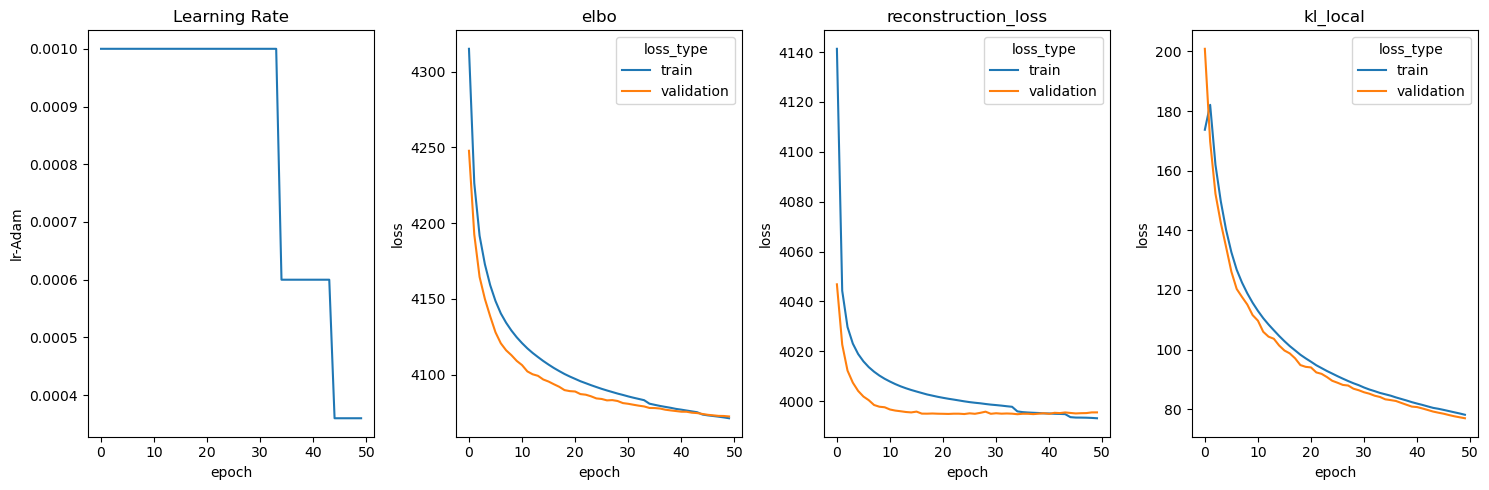

In [10]:
metrics_path = os.path.join(
    data_path, 'interim',
    author + '_scvi_mod',
    'overwrite', # overwrite_2
    'metrics.csv'
)

df = pd.read_csv(metrics_path)
fig, ax = plt.subplots(ncols = 4, figsize = (15, 5))


loss_cols = ['elbo', 'reconstruction_loss']#, 'kl_local']

i = 0
viz_df = df[df['lr-Adam'].notna()][['epoch', 'lr-Adam']]
viz_df.epoch = range(viz_df.shape[0])
sns.lineplot(viz_df, x = 'epoch', y = 'lr-Adam', ax = ax[i])
ax[i].set_title('Learning Rate')


df = df.groupby('epoch').mean()
for i_, loss_type in enumerate(['elbo', 'reconstruction_loss', 'kl_local']):
    i = i+1
    viz_df = df[[loss_type + '_train', loss_type + '_validation']].copy().reset_index()
    viz_df = pd.melt(viz_df, id_vars = 'epoch', var_name = 'loss_type', value_name = 'loss')
    viz_df.loss_type = viz_df.loss_type.apply(lambda x: x.split('_')[-1])
    sns.lineplot(viz_df, x = 'epoch', y = 'loss', hue = 'loss_type', ax = ax[i])
    ax[i].set_title(loss_type)

fig.tight_layout();

In [11]:
def get_scvi_normalized_expression(
    scvi_mod, 
    n_chunks: int, 
    library_size: float = 1e6, 
    batch_size: int = 1024, 
    sparse_output: bool = False
):
    """
    Runs scvi_mod.get_normalized_expression in memory-efficient chunks,
    aggregates results, and assigns to scvi_mod.adata.X as sparse CSR or dense NumPy array.

    Parameters
    ----------
    scvi_mod : scvi.model.SCVI
        Trained SCVI model.
    n_chunks : int
        Number of chunks to break the data into.
    library_size : float
        Library size for normalization.
    batch_size : int
        Batch size for model prediction.
    sparse_output : bool
        If True, aggregate as sparse CSR; else as dense NumPy array.
    """
    n_obs = scvi_mod.adata.n_obs
    n_vars = scvi_mod.adata.n_vars
    indices = np.arange(n_obs)
    chunk_size = int(np.ceil(n_obs / n_chunks))
    chunks = []

    for i in trange(n_chunks):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, n_obs)
        idx = indices[start:end]
        norm_expr = scvi_mod.get_normalized_expression(
            scvi_mod.adata[idx],
            library_size=library_size,
            batch_size=batch_size
        ).astype('float32').values

        # (Optional) Threshold small values to zero for more sparsity
        # norm_expr[np.abs(norm_expr) < 1e-3] = 0

        if sparse_output:
            chunk = sparse.csr_matrix(norm_expr)
        else:
            chunk = norm_expr
        chunks.append(chunk)
        utils.clear_memory()

    # Stack all chunks
    if sparse_output:
        scvi_mod.adata.X = sparse.vstack(chunks, format='csr')
    else:
        scvi_mod.adata.X = np.vstack(chunks)
    
    return scvi_mod.adata


print('Get counts')
# adata.layers['normalized_counts'] = adata.X.copy()
# this will replace normalized counts with scvi corrected counts
adata = get_scvi_normalized_expression(scvi_mod = scvi_mod,  
                                       n_chunks = 10, 
                                      library_size = 1e6, 
                                      batch_size = 1024, 
                                      sparse_output = False)

# print('Get latent')
# adata.obsm['X_scVI'] = scvi_mod.get_latent_representation(adata)
# del adata.layers['counts']
utils.clear_memory()

# print('Save anndata object')
# adata.write_h5ad(os.path.join(data_path, 'interim', author + '_scvi_counts.h5ad'))

Get counts


  0%|                                                                                                | 0/10 [00:00<?, ?it/s]

INFO     Received view of anndata, making copy.                                                                    


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 651 in adata.obs['G2M_score'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 580 in adata.obs['S_score'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)


...

INFO     Received view of anndata, making copy.                                                                    


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 11 in adata.obs['G2M_score'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 6 in adata.obs['S_score'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)


100%|███████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:37<00:00, 21.68s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:37<00:00, 21.72s/it]

In [12]:
# add hvg information from log1p data
for col in ['highly_variable', 'means', 'dispersions', 'dispersions_norm']:
    adata.var[col] = adata_norm.var[col].copy()
adata.uns['hvg'] = adata_norm.uns['hvg']
del adata_norm

# Embeddings

In [13]:
covariate_associations = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito']

## PCA Space

For embedding scvi activity in PC space:
- no centering, as scvi activities are already Z-scored
- don't use HVGs, as scvi activity feature space is already limited
- automated elbow selection from 1-50 PC components
- if using clustering, identify a resolution that best clusters with cell_line + drug, as those are the two sources of variance we are most interested in


In [14]:
file_prefix = os.path.join(data_path, 'processed', author + '_scvi_activity_pca')

In [15]:
adata, r2_df = ls.pc_pipeline(
    adata = adata,
    pert_ids = adata.obs.drug.unique(), # don't subset
    cat_ids = adata.obs.cell_line.unique(), # don't subset
    n_components = None, # estimate out of 50
    pert_col = 'drug',
    cat_col = 'cell_line',
    get_hvgs = False, 
    run_umap = True,
    covariate_associations = covariate_associations, 
    file_prefix = file_prefix,
    verbose = False,
    n_cores = n_cores,
    seed = 888,
    embkwrgs = {
        'cluster_data': False, 
        'scale': False,
        'pc_projection_tol': 1e-2,# typically 5e-4, but projection values are larger
        'pcakwrgs': {
            'use_highly_variable': True, # identified in log-normalized data
            'zero_center': True
        }    
    }
)


/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/latent_separation.py:282: UserWarning: Cannot reproduce scanpy pca projection
  warnings.warn('Cannot reproduce scanpy pca projection')


/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cell_line


  0%|                                                                                                | 0/11 [00:00<?, ?it/s]

...

 73%|████████████████████████████████████████████████████████████████                        | 8/11 [03:45<01:23, 27.88s/it]

 82%|████████████████████████████████████████████████████████████████████████                | 9/11 [04:10<00:53, 26.94s/it]

 91%|███████████████████████████████████████████████████████████████████████████████        | 10/11 [04:44<00:28, 28.94s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 11/11 [05:10<00:00, 28.09s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 11/11 [05:10<00:00, 28.22s/it]

Elbow selection:

The elbow was automatically identified at PC 11


''

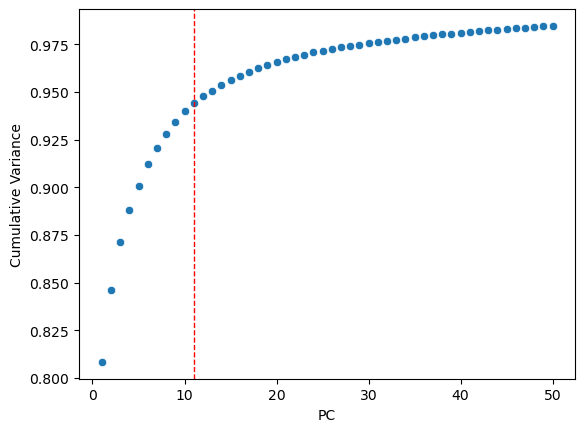

In [16]:
fig, ax = plt.subplots()
sns.scatterplot(
    y=np.cumsum(adata.uns['pca']['variance_ratio']),
    x=range(1, adata.uns['pca']['variance_ratio'].shape[0] + 1),
    ax=ax
)
ax.set_ylabel('Cumulative Variance')
ax.set_xlabel('PC')

n_pcs = adata.uns['pca']['pca_rank']
ax.axvline(x=n_pcs, color='red', linestyle='--', linewidth=1)

print('The elbow was automatically identified at PC {}'.format(n_pcs))
;

The two PC components that best univariately separate by drug are components 10 and 9 explaining 4.50% and 2.88% of variance, respectively
The two PC components that best univariately separate by cell_line are components 2 and 3 explaining 76.55% and 76.31% of variance, respectively


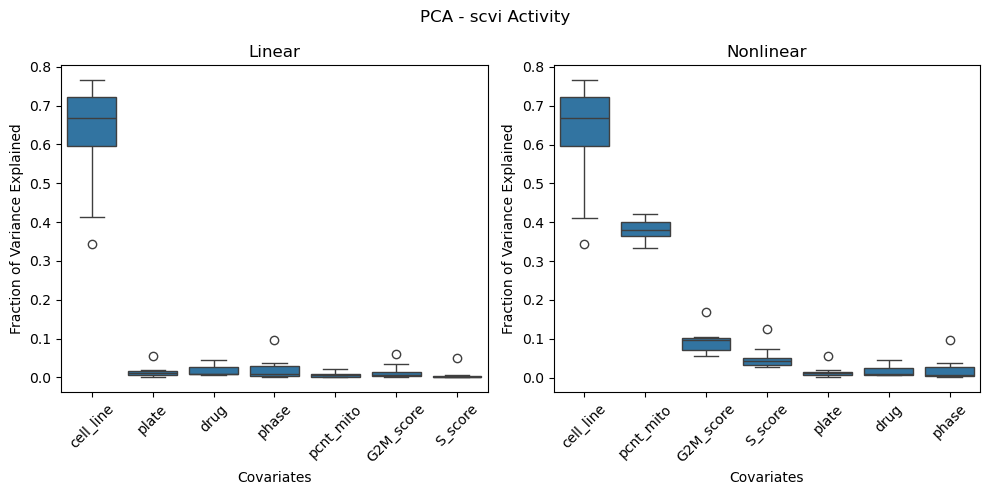

In [17]:
ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PCA - scvi Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
top_components_cl = ls.get_top_components(r2_df, top_components_cov = 'cell_line')

In [18]:
pd.melt(
    r2_df.set_index(r2_df.columns[0]), 
    id_vars='model_type', 
    var_name='covariate'
).groupby(['model_type','covariate']).median().sort_values(by = ['model_type', 'value'])


value
model_type covariate          
linear     S_score    0.001332
           G2M_score  0.005239
           pcnt_mito  0.005825
           phase      0.007847
           drug       0.008930
           plate      0.011824
           cell_line  0.668814
nonlinear  phase      0.007847
           drug       0.008929
           plate      0.011824
           S_score    0.042490
           G2M_score  0.097570
           pcnt_mito  0.380868
           cell_line  0.668814

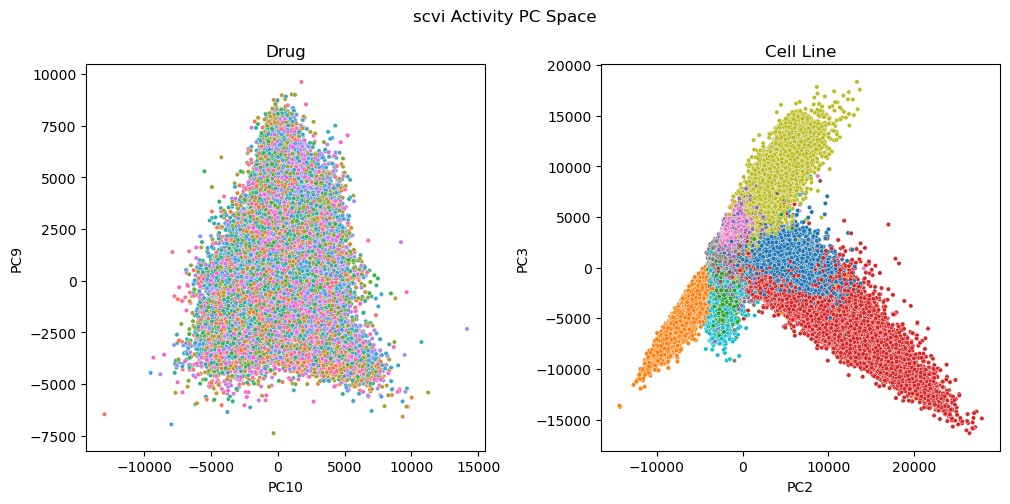

In [19]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'pca', 
    covariates = ['drug', 'cell_line'],
    panel_titles = ['Drug', 'Cell Line'],
    components = {'drug': top_components_drug, 
                  'cell_line': top_components_cl}, 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'scvi Activity PC Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

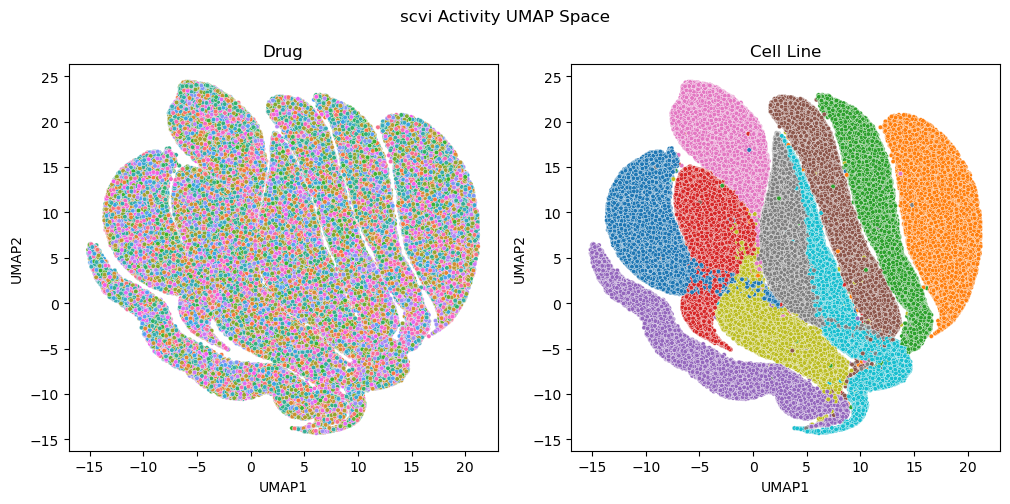

In [20]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'umap', 
    covariates = ['drug', 'cell_line'],
    panel_titles = ['Drug', 'Cell Line'],
    components = [1,2], 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'scvi Activity UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)

## PLS-DA 

For PLS-DA:
- again, we do not scale since the input is normalized
- we use our automated elbow analysis to identify the number of covariates
- umap is run categorically on drug
- we filter for HVGs for compute time (and bc this is more comparable with PCA)

In [21]:
file_prefix = os.path.join(data_path, 'processed', author + '_scvi_activity_pls')
filter_hvgs_pls = True

In [22]:
if filter_hvgs_pls:
    adata = adata[:, adata.var['highly_variable']]

In [23]:
adata, r2_df = ls.pls_da_pipeline(
    adata = adata, 
    pert_ids = adata.obs.drug.unique(), # don't subset
    cat_ids = adata.obs.cell_line.unique(), # don't subset
    n_components = None, 
    pert_col = 'drug', 
    cat_col = 'cell_line', 
    separate_by = 'perturbation', 
    control_confounders = [], 
    covariate_associations = covariate_associations,
    scale = False, # scvi activity already Z-scored
    run_umap = True, 
    file_prefix = file_prefix, 
    verbose = True,
    seed = seed, 
    n_cores = n_cores
)


Run elbow selection


  0%|                                                                                                | 0/25 [00:00<?, ?it/s]

  4%|███▍                                                                                 | 1/25 [09:26<3:46:25, 566.05s/it]

  8%|██████▊                                                                              | 2/25 [18:46<3:35:40, 562.63s/it]

 12%|██████████▏                                                                          | 3/25 [27:57<3:24:25, 557.51s/it]

...

 92%|███████████████████████████████████████████████████████████████████████████████▊       | 11/12 [05:02<00:27, 27.63s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 12/12 [05:27<00:00, 27.05s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 12/12 [05:27<00:00, 27.32s/it]


/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Get UMAP


In [24]:
adata.uns['pls']['model_fit']

{'n_components': 12,
 'accuracy': 0.16244470155856527,
 'explained_y': 0.040398128408151934}

''

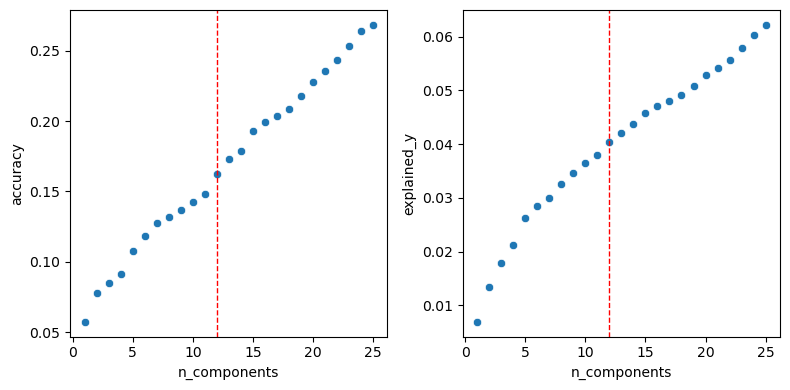

In [25]:
elbow_df = adata.uns['pls']['elbow_analysis']

n_components = adata.uns['pls']['model_fit']['n_components']
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
for (i, metric) in enumerate(['accuracy', 'explained_y']):
    sns.scatterplot(data = elbow_df, x = 'n_components', y = metric, ax = ax[i])
    ax[i].axvline(x=n_components, color='red', linestyle='--', linewidth=1)
   
    
fig.tight_layout()
;

The two PLS components that best univariately separate by drug are components 1 and 2 explaining 23.54% and 21.87% of variance, respectively
The two PLS components that best univariately separate by cell_line are components 7 and 6 explaining 68.23% and 59.37% of variance, respectively


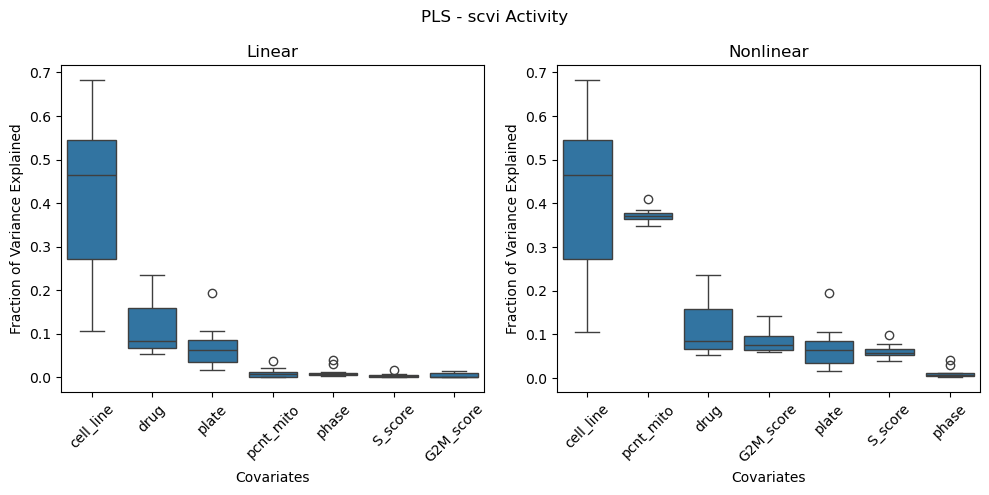

In [26]:
top_components = ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PLS - scvi Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
top_components_cl = ls.get_top_components(r2_df, top_components_cov = 'cell_line')

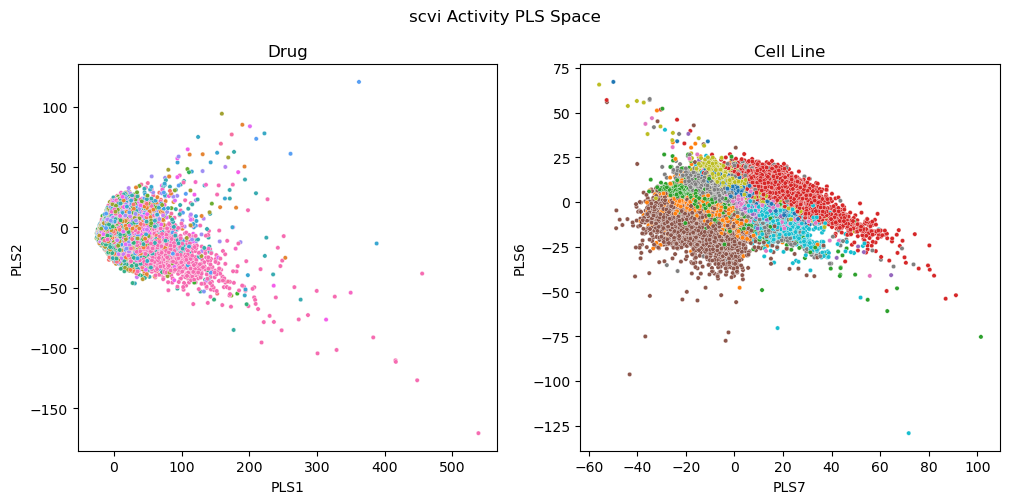

In [27]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'pls', 
    covariates = ['drug', 'cell_line'], 
    panel_titles = ['Drug', 'Cell Line'],
    components = {'drug': top_components_drug, 
                  'cell_line': top_components_cl}, 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'scvi Activity PLS Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

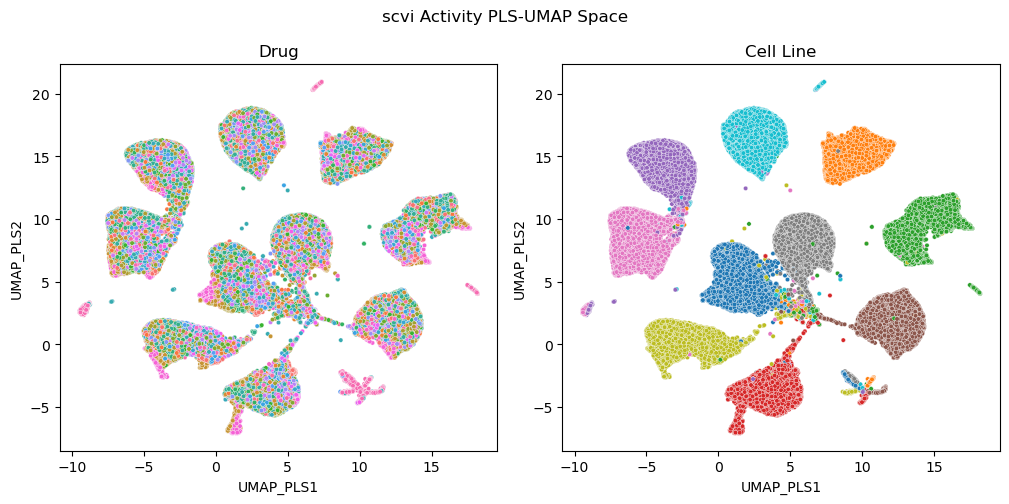

In [28]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'umap_pls', 
    covariates = ['drug', 'cell_line'], 
    panel_titles = ['Drug', 'Cell Line'],
    components = [1,2], 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'scvi Activity PLS-UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)